In [7]:
# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import Perceptron

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier

from sklearn.feature_selection import SelectKBest, chi2

In [8]:
#LOAD DATASET
df = pd.read_csv("Traffic_Accident.csv")

print(df.head())
print(df.info())

  Weather   Road_Type Time_of_Day  Traffic_Density  Speed_Limit  \
0   Rainy   City Road     Morning              1.0        100.0   
1   Clear  Rural Road       Night              NaN        120.0   
2   Rainy     Highway     Evening              1.0         60.0   
3   Clear   City Road   Afternoon              2.0         60.0   
4   Rainy     Highway     Morning              1.0        195.0   

   Number_of_Vehicles  Driver_Alcohol Accident_Severity      Road_Condition  \
0                 5.0             0.0               NaN                 Wet   
1                 3.0             0.0          Moderate                 Wet   
2                 4.0             0.0               Low                 Icy   
3                 3.0             0.0               Low  Under Construction   
4                11.0             0.0               Low                 Dry   

  Vehicle_Type  Driver_Age  Driver_Experience Road_Light_Condition  Accident  
0          Car        51.0               48

In [11]:
# HANDLE MISSING VALUE
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].mean())

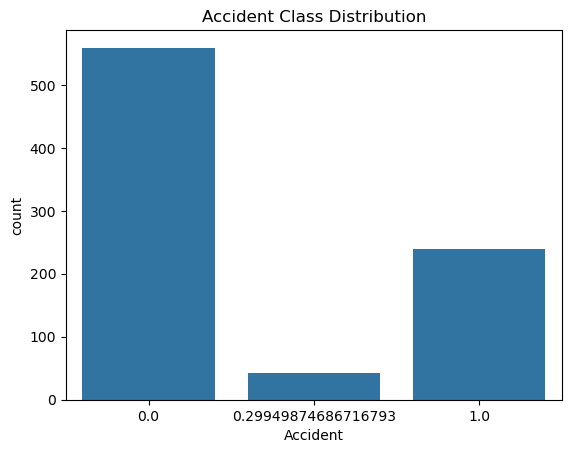

In [15]:
#Class Distribution Plot
sns.countplot(x=df["Accident"])
plt.title("Accident Class Distribution")
plt.show()

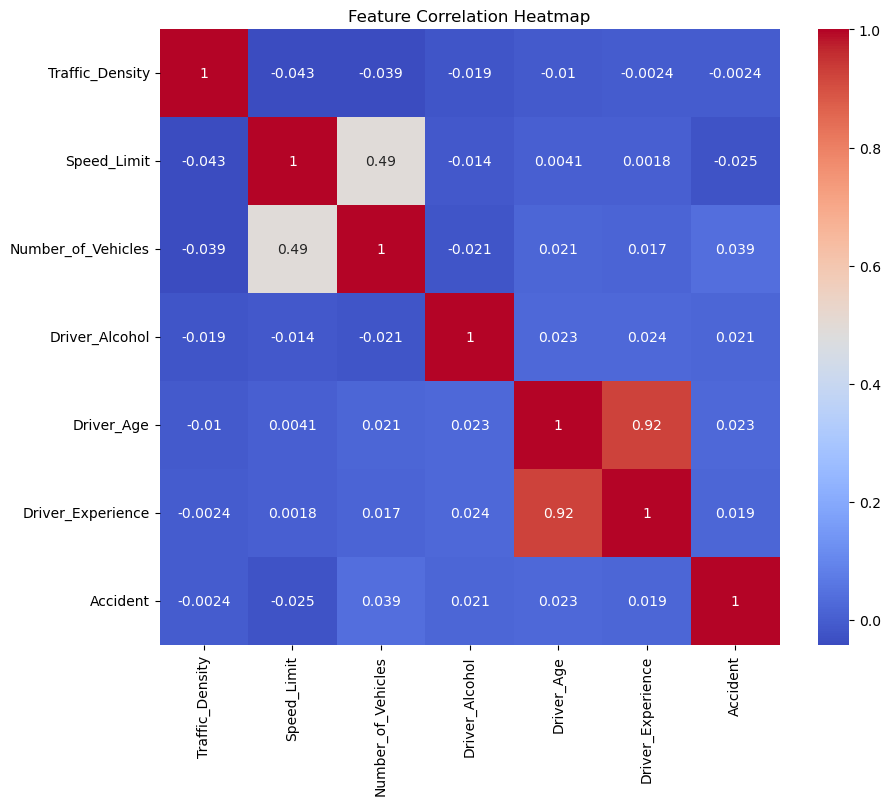

In [19]:
# CORRELATION HEATMAP (FIXED)
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Feature Correlation Heatmap")

plt.show()

In [31]:
# LABEL ENCODING
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [33]:
# FIX TARGET VARIABLE
# Convert Accident column into classification labels

df["Accident"] = df["Accident"].round().astype(int)

print(df["Accident"].unique())

[0 1]


In [35]:
# FEATURE SELECTION
X = df.drop("Accident", axis=1)
y = df["Accident"]

selector = SelectKBest(score_func=chi2, k=8)
X_selected = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]
print("Selected Features:", selected_features)

X = df[selected_features]

Selected Features: Index(['Weather', 'Road_Type', 'Speed_Limit', 'Number_of_Vehicles',
       'Road_Condition', 'Vehicle_Type', 'Driver_Age', 'Driver_Experience'],
      dtype='object')


In [37]:
#TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [39]:
# FEATURE SCALING
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

results = {}

In [41]:
# LMS (LINEAR REGRESSION)
lms_model = LinearRegression()
lms_model.fit(X_train, y_train)

lms_pred = lms_model.predict(X_test)
lms_pred = (lms_pred > 0.5).astype(int)

results['LMS'] = accuracy_score(y_test, lms_pred)

In [43]:
# LOGISTIC REGRESSION
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)
results['Logistic Regression'] = accuracy_score(y_test, log_pred)

In [45]:
log_model = LogisticRegression()

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

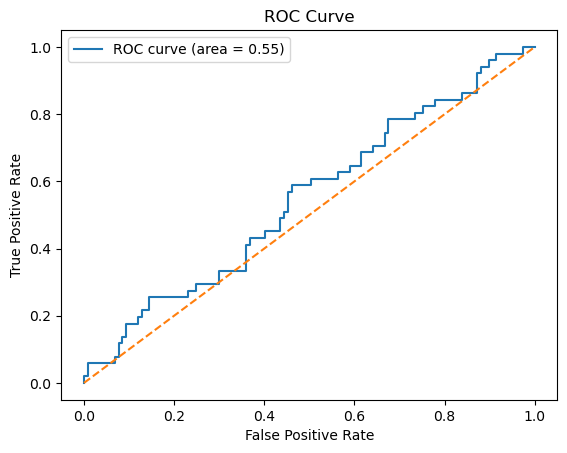

In [47]:
# ROC Curve
from sklearn.metrics import roc_curve, auc

y_pred_prob = log_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="ROC curve (area = %0.2f)" % roc_auc)

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [49]:
# PERCEPTRON
perc_model = Perceptron()
perc_model.fit(X_train, y_train)

perc_pred = perc_model.predict(X_test)
results['Perceptron'] = accuracy_score(y_test, perc_pred)

In [51]:
#  GDA (LDA Approximation)
gda_model = LinearDiscriminantAnalysis()
gda_model.fit(X_train, y_train)

gda_pred = gda_model.predict(X_test)
results['GDA'] = accuracy_score(y_test, gda_pred)

In [53]:
# NAIVE BAYES
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)
results['Naive Bayes'] = accuracy_score(y_test, nb_pred)

In [55]:
# SUPPORT VECTOR MACHINE
svm_model = SVC(kernel='rbf')
svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)
results['SVM'] = accuracy_score(y_test, svm_pred)

In [57]:
# BAGGING (RANDOM FOREST)
rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
results['Random Forest'] = accuracy_score(y_test, rf_pred)

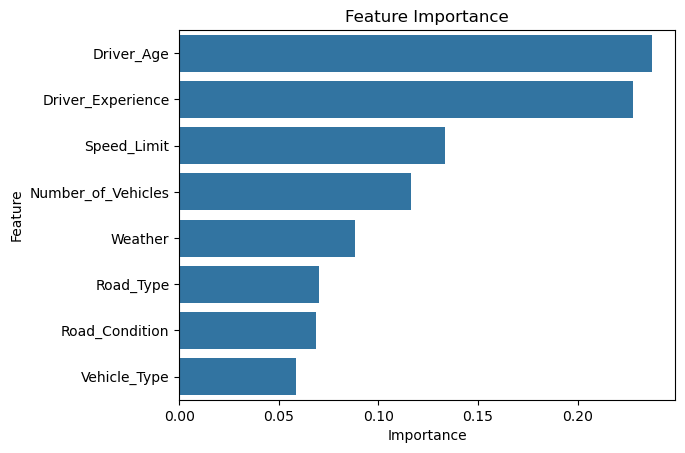

In [59]:
#Feature Importance Plot
importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": selected_features,
    "Importance": importances
})

feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)

sns.barplot(
    x=feature_importance_df["Importance"],
    y=feature_importance_df["Feature"]
)

plt.title("Feature Importance")
plt.show()

In [61]:
# BOOSTING (ADABOOST)
ada_model = AdaBoostClassifier(n_estimators=100)
ada_model.fit(X_train, y_train)

ada_pred = ada_model.predict(X_test)
results['AdaBoost'] = accuracy_score(y_test, ada_pred)

In [63]:
# MODEL COMPARISON
print("\nMODEL ACCURACY COMPARISON")

for model, acc in results.items():
    print(model, "=", acc)


MODEL ACCURACY COMPARISON
LMS = 0.6964285714285714
Logistic Regression = 0.6964285714285714
Perceptron = 0.4642857142857143
GDA = 0.6964285714285714
Naive Bayes = 0.6904761904761905
SVM = 0.6964285714285714
Random Forest = 0.7202380952380952
AdaBoost = 0.6964285714285714


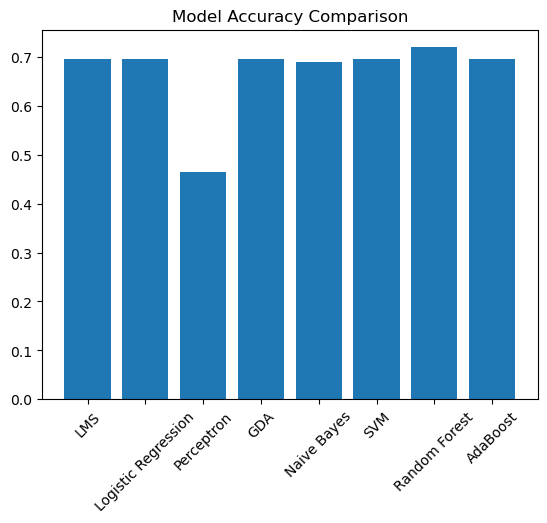

In [65]:
#Accuracy Comparison Graph
plt.bar(results.keys(), results.values())

plt.xticks(rotation=45)

plt.title("Model Accuracy Comparison")

plt.show()


BEST MODEL: Random Forest


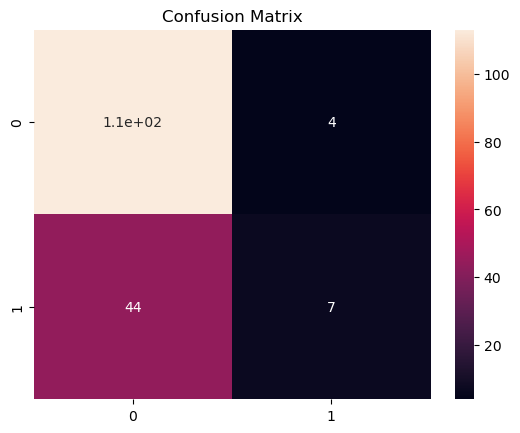

In [18]:
# CONFUSION MATRIX BEST MODEL
best_model = max(results, key=results.get)
print("\nBEST MODEL:", best_model)

sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True)
plt.title("Confusion Matrix")
plt.show()

In [19]:
#CLASSIFICATION REPORT
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.72      0.97      0.82       117
           1       0.64      0.14      0.23        51

    accuracy                           0.71       168
   macro avg       0.68      0.55      0.53       168
weighted avg       0.69      0.71      0.64       168

